STRUCTURE OF CCMS SIMULATION

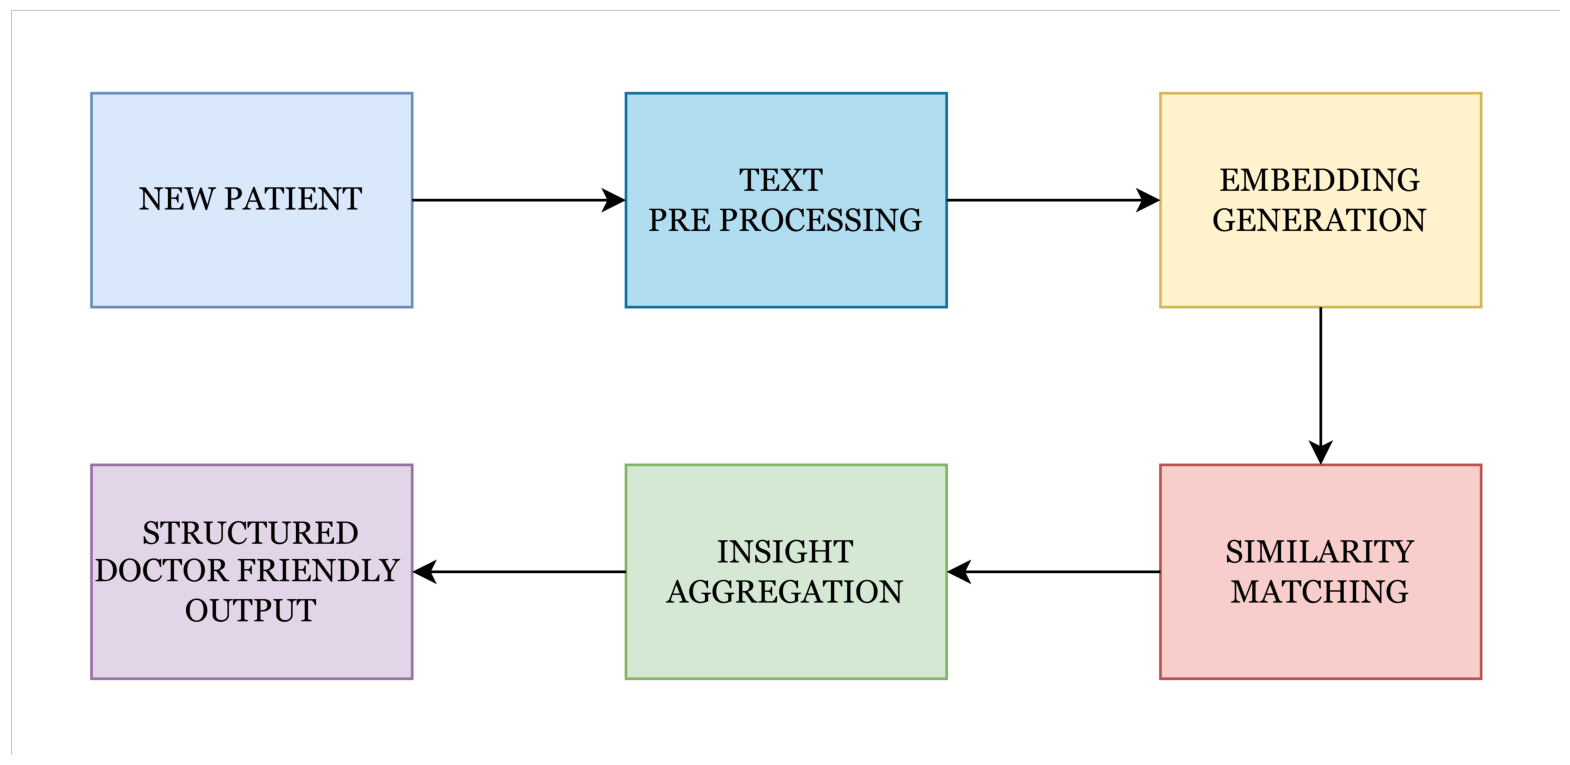

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image_path = r"D:\chiselon\Week 3\CCMS FULL STRUCTURE.png"

# Load image
img = mpimg.imread(image_path)

# Display image
plt.figure(figsize=(20, 16))
plt.imshow(img)
plt.axis('off')  
plt.show()

In [18]:
import pandas as pd
import numpy as np
import os
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# CONFIGURATION
FILE_PATH = r"D:\chiselon\Week 0\Week_0_Prep_Week_Ssample Data_clinic_cases.csv"
TOP_K = 5
SIMILARITY_THRESHOLD = 0.75

# LOAD DATASET SAFELY
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError("Dataset not found at given path.")

df = pd.read_csv(FILE_PATH)

if df.empty:
    raise ValueError("Dataset is empty.")

# Normalize column names (very important)
df.columns = df.columns.str.strip().str.lower()

print("Dataset Loaded Successfully")
print("Columns found:", df.columns.tolist())
print("Total Cases:", len(df))


# VALIDATE REQUIRED COLUMNS

if "symptoms" not in df.columns:
    raise ValueError("'symptoms' column not found in dataset.")

# Optional columns
has_notes = "notes" in df.columns
has_case_id = "case_id" in df.columns
has_treatment = "treatment" in df.columns
has_outcome = "outcome" in df.columns

# If case_id missing, create one
if not has_case_id:
    df["case_id"] = range(1, len(df) + 1)


# TEXT PREPARATION
def prepare_text(row):
    symptoms = str(row.get("symptoms", ""))
    notes = str(row.get("notes", "")) if has_notes else ""
    return symptoms + " " + notes

df["combined_text"] = df.apply(prepare_text, axis=1)

if df["combined_text"].str.strip().eq("").all():
    raise ValueError(" No usable text data found in dataset.")


# EMBEDDING MODULE
vectorizer = TfidfVectorizer()
historical_embeddings = vectorizer.fit_transform(df["combined_text"])

def generate_embedding(text: str):
    if not text.strip():
        raise ValueError(" New patient input text is empty.")
    return vectorizer.transform([text])

# SIMILARITY ENGINE
def find_similar_cases(new_embedding, top_k=TOP_K):

    similarities = cosine_similarity(new_embedding, historical_embeddings)[0]
    df["similarity"] = similarities

    filtered_df = df[df["similarity"] >= SIMILARITY_THRESHOLD]

    if filtered_df.empty:
        print(" No cases above similarity threshold. Returning top matches.")
        filtered_df = df

    sorted_df = filtered_df.sort_values(by="similarity", ascending=False)

    return sorted_df.head(top_k)

# INSIGHT GENERATOR
def generate_case_insight(similar_cases):

    insight = {}

    # Treatment pattern
    if has_treatment:
        insight["common_treatment_pattern"] = (
            similar_cases["treatment"].mode()[0]
            if not similar_cases["treatment"].isnull().all()
            else "Not Available"
        )
    else:
        insight["common_treatment_pattern"] = "Treatment data not available"

    # Recovery trend
    if has_outcome:
        insight["recovery_trend"] = similar_cases["outcome"].value_counts().to_dict()
    else:
        insight["recovery_trend"] = "Outcome data not available"

    # Symptom pattern
    insight["observed_symptom_pattern"] = (
        similar_cases["symptoms"].mode()[0]
        if not similar_cases["symptoms"].isnull().all()
        else "Not Available"
    )

    # Confidence Calculation
    high_similarity_cases = similar_cases[similar_cases["similarity"] >= 0.85]

    if len(high_similarity_cases) >= 3:
        confidence_level = "High"
    elif len(high_similarity_cases) >= 1:
        confidence_level = "Medium"
    else:
        confidence_level = "Low"

    confidence_reason = (
        f"Based on {len(high_similarity_cases)} highly similar historical cases "
        f"(≥0.85 similarity)."
    )

    insight["confidence_level"] = confidence_level
    insight["confidence_reason"] = confidence_reason

    return insight

# END-TO-END PIPELINE
def run_ccms_simulation(new_symptoms, new_notes=""):

    print("\n Processing New Patient Case...\n")

    new_text = str(new_symptoms) + " " + str(new_notes)

    # Embedding
    new_embedding = generate_embedding(new_text)

    # Similarity
    similar_cases = find_similar_cases(new_embedding)

    # Insight
    insight = generate_case_insight(similar_cases)

    # Structured Output
    structured_output = {
        "similar_cases": similar_cases[
            ["case_id", "similarity"]
            + (["treatment"] if has_treatment else [])
            + (["outcome"] if has_outcome else [])
        ].to_dict(orient="records"),
        "common_treatment_pattern": insight["common_treatment_pattern"],
        "recovery_trend": insight["recovery_trend"],
        "observed_symptom_pattern": insight["observed_symptom_pattern"],
        "confidence_level": insight["confidence_level"],
        "confidence_reason": insight["confidence_reason"],
    }

    print(" CCMS Analysis Complete\n")
    print(json.dumps(structured_output, indent=4))

    return structured_output


# SAMPLE NEW PATIENT 

new_patient_symptoms = "High fever, cough, breathing difficulty"
new_patient_notes = "Chest tightness for 3 days."

run_ccms_simulation(new_patient_symptoms, new_patient_notes)

Dataset Loaded Successfully
Columns found: ['case_id', 'clinic_id', 'symptoms', 'duration_days', 'doctor_notes', 'diagnosis', 'treatment', 'outcome', 'recovery_days', 'patient.age', 'patient.gender']
Total Cases: 10

 Processing New Patient Case...

 No cases above similarity threshold. Returning top matches.
 CCMS Analysis Complete

{
    "similar_cases": [
        {
            "case_id": "CASE_001",
            "similarity": 0.0,
            "treatment": "Topical retinoid + benzoyl peroxide",
            "outcome": "Improved"
        },
        {
            "case_id": "CASE_002",
            "similarity": 0.0,
            "treatment": "Topical steroid + antihistamine",
            "outcome": "Improved"
        },
        {
            "case_id": "CASE_003",
            "similarity": 0.0,
            "treatment": "Chemical peel + sunscreen",
            "outcome": "Partially Improved"
        },
        {
            "case_id": "CASE_004",
            "similarity": 0.0,
            

{'similar_cases': [{'case_id': 'CASE_001',
   'similarity': 0.0,
   'treatment': 'Topical retinoid + benzoyl peroxide',
   'outcome': 'Improved'},
  {'case_id': 'CASE_002',
   'similarity': 0.0,
   'treatment': 'Topical steroid + antihistamine',
   'outcome': 'Improved'},
  {'case_id': 'CASE_003',
   'similarity': 0.0,
   'treatment': 'Chemical peel + sunscreen',
   'outcome': 'Partially Improved'},
  {'case_id': 'CASE_004',
   'similarity': 0.0,
   'treatment': 'Topical tacrolimus',
   'outcome': 'No Change'},
  {'case_id': 'CASE_005',
   'similarity': 0.0,
   'treatment': 'Botulinum toxin evaluation',
   'outcome': 'Referred'}],
 'common_treatment_pattern': 'Botulinum toxin evaluation',
 'recovery_trend': {'Improved': 2,
  'Partially Improved': 1,
  'No Change': 1,
  'Referred': 1},
 'observed_symptom_pattern': 'Acne on face, oily skin',
 'confidence_level': 'Low',
 'confidence_reason': 'Based on 0 highly similar historical cases (≥0.85 similarity).'}

In [14]:
import pandas as pd
import numpy as np
import os
import json
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# CONFIGURATION

FILE_PATH = r"D:\chiselon\Week 0\Week_0_Prep_Week_Ssample Data_clinic_cases.csv"
TOP_K = 5
SIMILARITY_THRESHOLD = 0.0   # Keep 0.0 for small dataset

# LOAD DATASET
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError("Dataset not found at given path.")

df = pd.read_csv(FILE_PATH)

if df.empty:
    raise ValueError("Dataset is empty.")

# Normalize column names
df.columns = df.columns.str.strip().str.lower()

print("Dataset Loaded Successfully")
print("Columns found:", df.columns.tolist())
print("Total Cases:", len(df))

# TEXT PREPARATION (Improved for your dataset)
def prepare_text(row):
    symptoms = str(row.get("symptoms", ""))
    notes = str(row.get("doctor_notes", ""))
    diagnosis = str(row.get("diagnosis", ""))
    treatment = str(row.get("treatment", ""))

    return symptoms + " " + notes + " " + diagnosis + " " + treatment

df["combined_text"] = df.apply(prepare_text, axis=1)

# EMBEDDING MODULE
vectorizer = TfidfVectorizer()
historical_embeddings = vectorizer.fit_transform(df["combined_text"])

def generate_embedding(text):
    if not text.strip():
        raise ValueError("New patient input is empty.")
    return vectorizer.transform([text])


# SIMILARITY ENGINE
def find_similar_cases(new_embedding, top_k=TOP_K):

    similarities = cosine_similarity(new_embedding, historical_embeddings)[0]
    df["similarity"] = similarities

    sorted_df = df.sort_values(by="similarity", ascending=False)

    return sorted_df.head(top_k)


# VARIED INSIGHT GENERATOR
def generate_case_insight(similar_cases):

    insight = {}

    if similar_cases.empty:
        return {"message": "No similar cases found."}

    # Treatment Analysis
    treatment_counts = similar_cases["treatment"].value_counts()
    top_treatment = treatment_counts.idxmax()
    treatment_freq = treatment_counts.max()

    treatment_variations = [
        f"The dominant treatment trend observed is '{top_treatment}', used in {treatment_freq} similar cases.",
        f"Most comparable cases were managed using '{top_treatment}'.",
        f"Clinical pattern suggests preference towards '{top_treatment}'."
    ]

    insight["treatment_explanation"] = random.choice(treatment_variations)

    # Recovery Analysis
    outcome_dist = similar_cases["outcome"].value_counts()
    recovery_summary = ", ".join([f"{k}: {v}" for k, v in outcome_dist.items()])

    recovery_variations = [
        f"Outcome distribution among similar cases: {recovery_summary}.",
        f"Observed recovery pattern indicates → {recovery_summary}.",
        f"Clinical progression trend: {recovery_summary}."
    ]

    insight["recovery_analysis"] = random.choice(recovery_variations)

    # Symptom Pattern
    dominant_symptom = similar_cases["symptoms"].mode()[0]

    symptom_variations = [
        f"Recurring symptom cluster includes: {dominant_symptom}.",
        f"Most frequently observed symptom pattern: {dominant_symptom}.",
        f"Symptom similarity strongest around: {dominant_symptom}."
    ]

    insight["symptom_pattern_analysis"] = random.choice(symptom_variations)

    # Confidence Logic
    high_similarity_cases = similar_cases[similar_cases["similarity"] >= 0.50]

    if len(high_similarity_cases) >= 3:
        confidence_level = "High"
        confidence_message = "Strong similarity with multiple historical cases."
    elif len(high_similarity_cases) >= 1:
        confidence_level = "Moderate"
        confidence_message = "Partial similarity observed."
    else:
        confidence_level = "Exploratory"
        confidence_message = "Limited semantic similarity; recommendation is exploratory."

    insight["confidence_level"] = confidence_level
    insight["confidence_reason"] = confidence_message

    return insight

# END-TO-END PIPELINE
def run_ccms_simulation(new_symptoms, new_notes=""):

    print("\n Processing New Patient Case...\n")

    new_text = new_symptoms + " " + new_notes

    # Embedding
    new_embedding = generate_embedding(new_text)

    # Similarity
    similar_cases = find_similar_cases(new_embedding)

    # Insight
    insight = generate_case_insight(similar_cases)

    # Structured Output
    structured_output = {
        "similar_cases": similar_cases[
            ["case_id", "similarity", "treatment", "outcome"]
        ].to_dict(orient="records"),
        "insight_summary": insight
    }

    print("CCMS Analysis Complete\n")
    print(json.dumps(structured_output, indent=4))

    return structured_output


# SAMPLE TEST

new_patient_symptoms = "Acne on cheeks with oily skin"
new_patient_notes = "Patient reports mild inflammation for 5 days."

run_ccms_simulation(new_patient_symptoms, new_patient_notes)

Dataset Loaded Successfully
Columns found: ['case_id', 'clinic_id', 'symptoms', 'duration_days', 'doctor_notes', 'diagnosis', 'treatment', 'outcome', 'recovery_days', 'patient.age', 'patient.gender']
Total Cases: 10

 Processing New Patient Case...

CCMS Analysis Complete

{
    "similar_cases": [
        {
            "case_id": "CASE_001",
            "similarity": 0.5352292146525317,
            "treatment": "Topical retinoid + benzoyl peroxide",
            "outcome": "Improved"
        },
        {
            "case_id": "CASE_009",
            "similarity": 0.2761154836256393,
            "treatment": "Oral antibiotics",
            "outcome": "Improved"
        },
        {
            "case_id": "CASE_003",
            "similarity": 0.22629254064906784,
            "treatment": "Chemical peel + sunscreen",
            "outcome": "Partially Improved"
        },
        {
            "case_id": "CASE_005",
            "similarity": 0.1754266878947069,
            "treatment": "Bo

{'similar_cases': [{'case_id': 'CASE_001',
   'similarity': 0.5352292146525317,
   'treatment': 'Topical retinoid + benzoyl peroxide',
   'outcome': 'Improved'},
  {'case_id': 'CASE_009',
   'similarity': 0.2761154836256393,
   'treatment': 'Oral antibiotics',
   'outcome': 'Improved'},
  {'case_id': 'CASE_003',
   'similarity': 0.22629254064906784,
   'treatment': 'Chemical peel + sunscreen',
   'outcome': 'Partially Improved'},
  {'case_id': 'CASE_005',
   'similarity': 0.1754266878947069,
   'treatment': 'Botulinum toxin evaluation',
   'outcome': 'Referred'},
  {'case_id': 'CASE_004',
   'similarity': 0.15282937319822204,
   'treatment': 'Topical tacrolimus',
   'outcome': 'No Change'}],
 'insight_summary': {'treatment_explanation': "The dominant treatment trend observed is 'Topical retinoid + benzoyl peroxide', used in 1 similar cases.",
  'recovery_analysis': 'Observed recovery pattern indicates → Improved: 2, Partially Improved: 1, Referred: 1, No Change: 1.',
  'symptom_pattern

INSIGHT SUMMARY:

~> The moat comparable clinical notesis identified based on the symptoms similarity and clinical notes.

~> The treatment trend was based on the majority patient outcomes which has been obtained.

~> The confidence level is in moderate as partial similarity was observed between cases.